In [67]:
%load_ext autoreload
%autoreload 2   

import arviz as az
import numpy as np
import pandas as pd

from pyprojroot import here

import pymc as pm

import mmm_utils.plot as mmm_plot
import mmm_utils.post_modeling as mmm_post_plot
from mmm_utils import Timeline
from mmm_utils.data_logger import data_logger

data_logger.change_dir(here() / "work" / "logs")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the data and plotting spend and sales

In [68]:
file_path = here() / "examples" / "synthetic_mm_data.csv"
data = pd.read_csv(file_path, sep=";", decimal=".").fillna(0)

data["date"] = pd.to_datetime(data["date"])
data["intercept"] = 1
data["trend"] = np.linspace(0, 1, len(data))

media = ["TV", "SEA", "Social"]
controls = ["intercept", "trend", "promo", "price"]

X = data[media + controls + ["date"]]
y = data["y"]

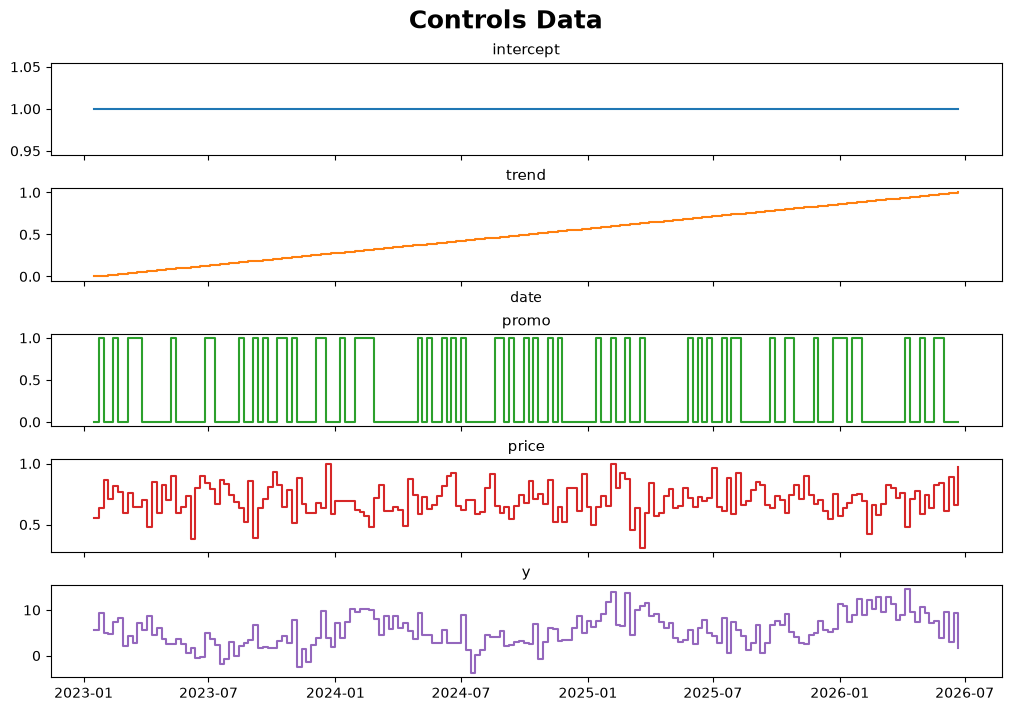

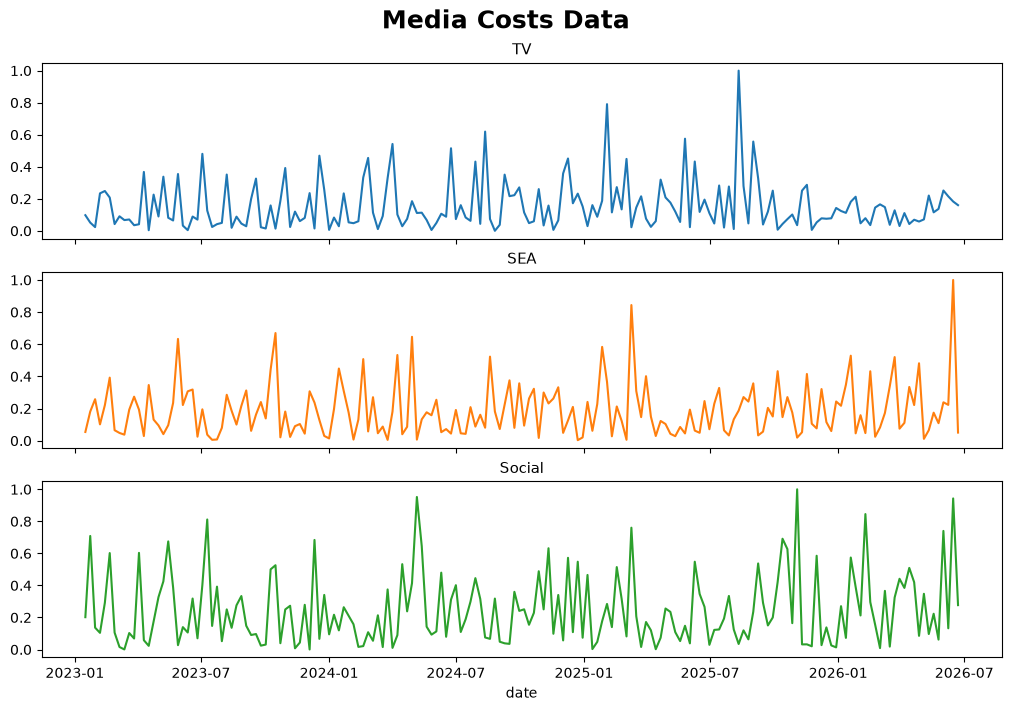

In [69]:
fig, axes = mmm_plot.plot_controls_variable(data, controls + ["y"])
fig, axes = mmm_plot.plot_media_costs(data, media)

## Modeling

In [70]:
from mmm_utils.modeling.mmm import MMM, MMMConfig, MediaTransformSpec
from mmm_utils.modeling.prior import PriorSpec, plot_prior_vs_posterior
from mmm_utils.modeling import Interaction, BetaPriors

In [71]:
interaction = Interaction(
    formulas={
        "TV": "1",
        "SEA": "1 + TV",
        "Social": "1 + TV",
    },
    media=media,
    # is_shared_with=[("TV", "SEA", "Social")],
)
print("Priors that need to be defined :")
interaction.get_unique_parameter_names()

Priors that need to be defined :


{'beta_interaction_TV'}

In [72]:
beta_priors = BetaPriors(
    interaction=interaction,
    priors={"beta_interaction_TV": PriorSpec("HalfNormal", {"sigma": 0.5})},
    season=PriorSpec("Laplace", {"mu": 0.0, "b": np.array([0.5, 0.5, 0.1, 0.1])}),
)

In [73]:
cfg = MMMConfig(
    media_names=media,
    control_names=controls,
    seasonality_order=2,
    beta_priors=beta_priors,
    media_transforms={
        "TV": MediaTransformSpec(
            adstock="GeometricDelayed",
            adstock_params={"l_max": 12},
            adstock_priors={
                "alpha": PriorSpec("Beta", {"alpha": 4.0, "beta": 0.5}),
                "theta": PriorSpec("Normal", {"mu": 2, "sigma": 0.2}),
            },
            saturation="Logistic",
            saturation_params={},
            saturation_priors={
                "lam": PriorSpec("LogNormal", {"mu": 0.0, "sigma": 1.0})
            },
        ),
        "SEA": MediaTransformSpec(
            adstock="Geometric",
            adstock_params={"l_max": 12},
            adstock_priors={"alpha": PriorSpec("Beta", {"alpha": 2.0, "beta": 2.0})},
            saturation="Logistic",
        ),
        "Social": MediaTransformSpec(
            adstock="Geometric",
            saturation="Logistic",
            saturation_params={"lam": 0.5},
        ),
    },
)

mmm = MMM(cfg)

#### Model Building

In [74]:
mmm.build(X, y, rescale=True)

XTensorType{dtype='float64', shape=(None, 3), dims=('date', 'media')}
XTensorType{dtype='float64', shape=(None, 3), dims=('date', 'media')}


#### Model Fitting

In [75]:
mmm.fit(
    draws=500,
    tune=500,
    chains=1,
    cores=1,
    target_accept=0.975,
)
# _ = mmm.compute_contributions()

NUTS[numpyro]: [beta_interaction_TV, beta_media, beta_control, beta_season, adstock_alpha[TV], adstock_theta[TV], saturation_lam[TV], adstock_alpha[SEA], sigma]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/usr/lib/python3.12/functools.py:909: UserWarning: Skipping Check{0 < alpha <= 1} Op (assertion: 0 < alpha <= 1) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: UserWarning: Skipping Check{0 <= theta < l_max} Op (assertion: 0 <= theta < l_max) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: UserWarning: Skipping Check{lam must be positive} Op (assertion: lam must be positive) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
sample: 100%|██████████| 1000/1000 [00:16<00:00, 61.06it/s, 63 steps of size 4.61e-02. acc. prob=0.98] 
/home/acaillebotte/

In [76]:
mmm.sample_posterior_predictive()

Sampling: [y]


Output()

Sampling: [adstock_alpha[SEA], adstock_alpha[TV], adstock_theta[TV], beta_control, beta_interaction_TV, beta_media, beta_season, saturation_lam[TV], sigma, y]


In [77]:
mmm.idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                          (chain: 1, draw: 500, control: 4,
│                                             season: 4, interaction_TV: 2, media: 3,
│                                             date: 180)
│       Coordinates:
│         * chain                            (chain) int64 8B 0
│         * draw                             (draw) int64 4kB 0 1 2 3 ... 497 498 499
│         * control                          (control) <U9 144B 'intercept' ... 'price'
│         * season                           (season) <U6 96B 'sin[1]' ... 'cos[2]'
│         * interaction_TV                   (interaction_TV) <U6 48B 'SEA' 'Social'
│         * media                            (media) <U6 72B 'SEA' 'Social' 'TV'
│         * date                             (date) datetime64[us] 1kB 2023-01-16 ......
│       Data variables: (12/13)
│           beta_control                     (chain, draw, control) float64 16kB ...
│           beta_season                      (chain, draw, season) float64 16kB ...
│           adstock_theta[TV]                (chain, draw) float64 4kB ...
│           beta_interaction_TV              (chain, draw, interaction_TV) float64 8kB ...
│           beta_media                       (chain, draw, media) float64 12kB ...
│           adstock_alpha[TV]                (chain, draw) float64 4kB ...
│           ...                               ...
│           adstock_alpha[SEA]               (chain, draw) float64 4kB ...
│           sigma                            (chain, draw) float64 4kB ...
│           media_contribution               (chain, draw, date, media) float64 2MB ...
│           total_media_contribution         (chain, draw, date) float64 720kB ...
│           control_contribution             (chain, draw, date, control) float64 3MB ...
│           yearly_seasonality_contribution  (chain, draw, date) float64 720kB ...
│       Attributes:
│           created_at:                 2026-06-26T07:59:32.921859+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          numpyro
│           inference_library_version:  0.21.0
│           sampling_time:              24.422083
│           tuning_steps:               500
├── Group: /sample_stats
│       Dimensions:          (chain: 1, draw: 500)
│       Coordinates:
│         * chain            (chain) int64 8B 0
│         * draw             (draw) int64 4kB 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│       Data variables:
│           acceptance_rate  (chain, draw) float64 4kB ...
│           step_size        (chain, draw) float64 4kB ...
│           diverging        (chain, draw) bool 500B ...
│           energy           (chain, draw) float64 4kB ...
│           n_steps          (chain, draw) int64 4kB ...
│           tree_depth       (chain, draw) int64 4kB 6 6 6 6 6 6 6 7 ... 6 6 6 7 7 7 6 6
│           lp               (chain, draw) float64 4kB ...
│       Attributes:
│           created_at:                 2026-06-26T07:59:32.943091+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /log_likelihood
│       Dimensions:  (chain: 1, draw: 500, date: 180)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│         * date     (date) datetime64[us] 1kB 2023-01-16 2023-01-23 ... 2026-06-22
│       Data variables:
│           y        (chain, draw, date) float64 720kB ...
│       Attributes:
│           created_at:                 2026-06-26T07:59:32.945697+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creat

In [ ]:
pm.model_to_graphviz(model=mmm.model)

## Post-modeling analysis

In [ ]:
fig, ax = mmm_post_plot.plot_posterior_predictive_y(
    mmm, add_seasonality=True, add_residuals=True
)

In [ ]:
az.residual_r2(mmm.idata, "y", group="posterior_predictive")

In [ ]:
def compute_mape(
    y_true: np.ndarray, y_pred: np.ndarray, epsilon: float = 1e-8
) -> float:
    """Compute Mean Absolute Percentage Error (MAPE).

    Parameters
    ----------
    y_true : np.ndarray
        Ground-truth target values.
    y_pred : np.ndarray
        Predicted target values.
    epsilon : float, default=1e-8
        Small value used to avoid division by zero.

    Returns
    -------
    float
        MAPE expressed as a percentage.
    """
    y_true_safe = np.where(np.abs(y_true) < epsilon, epsilon, y_true)
    return float(np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100.0)


posterior_predictive_mean = (
    mmm.idata.posterior_predictive["y"].mean(dim=["chain", "draw"]).values.squeeze()
)
y_true_values = y.to_numpy(dtype=float) / mmm.scale("y")

mape_score = compute_mape(y_true_values, posterior_predictive_mean)
print(f"MAPE: {mape_score:.2f}%")

## ROPE analysis & Estimation printing

In [ ]:
mmm_post_plot.rope_probability_test(
    posterior=mmm.idata.posterior,
    var=cfg.var_names(),
    rope=(-0.1, 0.1),
    verbatim=False,
)

In [ ]:
estim = (
    az.summary(data=mmm.idata, var_names=cfg.var_names())
    .reset_index()
    .rename(columns={"index": "parameter"})
)
data_logger.direct_to_csv("estimations.csv", dataframe=estim)

In [ ]:
estim

In [ ]:
all_beta = mmm.idata.posterior.beta_media
data_logger.direct_to_csv(
    "posterior_beta_draws.csv", dataframe=all_beta.to_dataframe().reset_index()
)


import matplotlib.pyplot as plt


beta_media_samples = [
    all_beta.sel(media=media_name).values.reshape(-1) for media_name in media
]
positions = np.arange(1, len(media) + 1)
cmap = plt.get_cmap("tab10")
colors = cmap(np.linspace(0, 1, len(media)))

fig, ax = plt.subplots(figsize=(8, 5))

# Horizontal boxplot (background)
box_parts = ax.boxplot(
    beta_media_samples,
    positions=positions,
    widths=0.25,
    patch_artist=True,
    showfliers=False,
    vert=False,
    zorder=2,
)

# Horizontal violin plot (foreground)
violin_parts = ax.violinplot(
    beta_media_samples,
    positions=positions,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    vert=False,
)

for idx in range(len(media)):
    patch = box_parts["boxes"][idx]
    patch.set_facecolor(colors[idx])
    patch.set_edgecolor("black")
    patch.set_alpha(0.75)

    body = violin_parts["bodies"][idx]
    body.set_facecolor(colors[idx])
    body.set_edgecolor("black")
    body.set_alpha(1.0)
    body.set_zorder(1)

# --- Mean ---
means = np.array([samples.mean() for samples in beta_media_samples])
ax.scatter(means, positions, color="black", marker="o", s=40, zorder=3)
# --- Median ---
medians = np.array([np.median(samples) for samples in beta_media_samples])
ax.scatter(medians, positions, color="black", marker="x", s=55, zorder=4)

ax.set_yticks(positions)
ax.set_yticklabels(media)
ax.set_xlabel("Posterior samples")
ax.set_ylabel("Media channel")
ax.set_title("Posterior distribution of beta_media by media channel")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()

In [ ]:
estim = (
    az.summary(data=mmm.idata, var_names=cfg.var_names())
    .reset_index()
    .rename(columns={"index": "parameter"})
)

value_columns = [col for col in estim.columns if col != "parameter"]
estim[value_columns] = (
    estim[value_columns].apply(pd.to_numeric, errors="coerce").astype(float)
)

In [ ]:
def robustness_check(estim, filter=None):
    def _classify(lo: float, hi: float, center: float) -> dict:
        """Return the level dict for the given ETI 89% bounds.

        Parameters
        ----------
        lo, hi   : ETI 89% lower / upper bounds (eti89_lb, eti89_ub).
        center   : posterior mean used as point estimate for relative width.
        """
        overlaps_zero = lo < 1e-9
        # Compute relative width as a fraction of the center (mean) value.
        rel_width = (hi - lo) / max(abs(center), 1e-9)

        if not overlaps_zero and rel_width <= 0.30:
            return "Robuste"
        if not overlaps_zero and rel_width <= 0.80:
            return "Acceptable"
        if overlaps_zero and rel_width > 0.80:
            return "Non identifié"
        return "Fragile"

    results = []
    for _, row in estim.iterrows():
        level = _classify(row["eti89_lb"], row["eti89_ub"], row["mean"])
        results.append({"parameter": row["parameter"], "robustness_level": level})

    if filter is not None:
        results = [r for r in results if r["robustness_level"] == filter]

    return pd.DataFrame(results)


robustness_check(estim, "Fragile")

In [ ]:
high_mcse_variables = mmm_post_plot.summarize_high_mcse_mean(estim)

high_mcse_variables.round({"mcse_over_sd": 2})

In [ ]:
# signal_std = np.std(y_true)
# noise_std = estim.loc[estim["parameter"] == "sigma", "mean"].values[0]
# snr = signal_std / noise_std

# print(f"Signal std: {signal_std:.4f}")
# print(f"Noise std (sigma): {noise_std:.4f}")
# print(f"Signal-to-Noise Ratio (SNR): {snr:.2f}")

In [ ]:
mmm_post_plot.adstock_to_half_life(mmm, media).round(
    {"adstock_alpha": 3, "half_life": 2}
)

## Ploting priors and posteriors

In [ ]:
def plot_params_prior_cs_posterior(var_prefix):
    media_found = [m for m in media if f"{var_prefix}[{m}]" in cfg.var_names()]
    if len(media_found) == 0:
        return None

    return plot_prior_vs_posterior(
        mmm,
        var_prefix,
        media_found,
        seperately=True,
    )

In [ ]:
from dataclasses import dataclass, field

import re
from typing import Literal

import numpy as np

import pymc as pm
import pymc.dims as pmd


import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
plot_prior_vs_posterior(
    mmm, "product_media", ["cospirit"], seperately=True, figsize=(6, 6)
)

In [ ]:
plot_prior_vs_posterior(mmm, "intercept", [""], seperately=True, figsize=(6, 6))
plot_prior_vs_posterior(mmm, "beta_media", media, seperately=True)
plot_prior_vs_posterior(mmm, "beta_control", controls, seperately=True)
plot_prior_vs_posterior(
    mmm,
    "beta_season",
    mmm.idata.posterior.season.values,
    seperately=True,
    figsize=(6, 6),
)
plot_params_prior_cs_posterior("saturation_n")
plot_params_prior_cs_posterior("saturation_k")
plot_params_prior_cs_posterior("saturation_lam")
plot_params_prior_cs_posterior("adstock_alpha")
plot_params_prior_cs_posterior("adstock_theta")
plot_params_prior_cs_posterior("umbrella")

### Adstock Effects Interpretation

In [ ]:
fig, ax = mmm_post_plot.plot_adstock_effects(data, mmm, media=media)

for date_fracture in date_fractures:
    ax.axvline(
        x=date_fracture,
        color="red",
        linestyle="--",
        label=f"Fracture : {date_fracture.date()}",
    )

## Timeline

In [ ]:
timeline = Timeline(
    mmm.idata.posterior,
    data,
    media=media,
    controls=controls,
    baseline_components=[],  # "control", "yearly_seasonality"],
    target_scale=mmm.scale("y"),
    target="nb_requetes_carto",
)

timeline.outcome_df.head()

In [ ]:
fig, ax = mmm_plot.plot_contributions(
    timeline,
    channels=media + controls + ["yearly_seasonality"],  # + ["is_closed"],
    decomposition=False,
    plot_y=True,
    remove_baseline=False,
    ascending=False,
)
_ = ax.set_ylabel("Web Revenue Hotel")
fig.savefig(here() / "work" / "contributions.png", dpi=300, bbox_inches="tight")

In [ ]:
_ = mmm_plot.plot_summary_contributions(
    timeline,
    controls=["yearly_seasonality", "cospirit"],
    baseline_override=["trend"],  # "trend_1", "trend_2"],
)

_ = mmm_plot.plot_summary_contributions_per_media(
    timeline, controls=controls + ["trend", "cospirit"]
)

_ = mmm_plot.plot_summary_contributions_per_media(
    timeline, baseline_override=["yearly_seasonality"] + controls
)

# Saturation & Optimization

In [ ]:
saturation_curves = mmm.sample_saturation_curves(x_max=2.0)

In [ ]:
media_scales = mmm.scale("media")

saturation = []
for i, m in enumerate(media):
    curve = saturation_curves[m]
    sat_name = f"saturation_{m}"

    xx = (curve.coords["x"]).values * media_scales[m]
    beta = (
        mmm.idata.posterior[f"beta_media"]
        .sel(media=m)
        .mean(dim=["chain", "draw"])
        .values
    )
    yy = beta * curve.mean(dim=["chain", "draw"]).values * mmm.scale("y")

    saturation.append(
        {
            "name": m,
            "values": {str(int(xx[k])): float(yy[k]) for k in range(len(xx))},
        }
    )

_ = mmm_plot.plot_saturation_curves(saturation_curves, mmm, data=data, media=media)

In [ ]:
from mmm_utils.optimizer.optimizer import Optimizer
import xarray as xr

current_budget = data[media].mean().to_dict()

optimizer = Optimizer(mmm)

optimizer.set_campaign(
    starting_date=data["date"].max() + pd.Timedelta(weeks=1),
    campaign_period=4,
    budget_by_media=current_budget,
)

flexibilities = {"low": 0.2, "medium": 0.4, "high": 0.6}

total_budget = sum(current_budget.values()) * 4
print(f"total budget = {total_budget}")


def get_recommended_budget(flex):
    print(flex)

    def lower_upper_bound(b, f):  # pylint: disable=missing-function-docstring, missing-return-doc
        return [b * (1 - f), b * (1 + f)]

    budget_bounds = [lower_upper_bound(b, flex) for _, b in current_budget.items()]

    budget_optimized_cst, res_cst = optimizer.optimize(
        budget_bounds,
        total_budget,
        constant_budget=True,
    )

    return budget_optimized_cst


all_budgets = {
    type: get_recommended_budget(flexibilities[type])[0, :]
    for type in flexibilities.keys()
}

In [ ]:
total_budget = data[media].sum().to_dict()
plan = all_budgets["medium"]
x = pd.DataFrame(
    {
        "media": current_budget.keys(),
        "current_budget": current_budget.values(),
        "plan": plan,
    },
)

x["reco"] = x["plan"] / sum(x["current_budget"]) * 100
x["change"] = x["plan"] / x["current_budget"] * 100 - 100

x["current_budget"] = total_budget.values()
x["plan"] = x["reco"] * sum(x["current_budget"]) / 100

data_logger.direct_to_csv("budget_recommendations.csv", dataframe=x)
x.round({"current_budget": 0, "plan": 0, "reco": 1})

In [ ]:
from mmm_pptx import generate_project_files

generate_project_files(
    data,
    kpi="nb_requetes_carto",
    kpi_label="Nombre de requêtes carto",
    media=media,
    tv_reference="TV Classique",
    client_name="Refashion",
    controls=[],
    dir=here() / "pptx_data",
)

# Mongo

In [ ]:
1 / 0

In [ ]:
timeline = Timeline(
    mmm.idata.posterior,
    data=data,
    media=media,
    controls=controls,
    target="nb_requetes_carto",
    baseline_components=["control", "yearly_seasonality"],
    target_scale=mmm.scale("y"),
)
_ = mmm_plot.plot_summary_contributions_per_media(timeline)

_ = mmm_plot.plot_summary_contributions(
    timeline,
    controls=[],
    baseline_override=[],
)

In [ ]:
from datetime import datetime, UTC
import os
from pymongo import MongoClient
import pymongo
from dotenv import load_dotenv

load_dotenv()

CODE_MODULE = "MMM_REFASHION"
DISPLAY_MONGO = {k: k for k in media}
recommendations = [
    {
        "name": m,
        "spend": {type: float(all_budgets[type][i]) for type in flexibilities.keys()},
    }
    for i, m in enumerate(media)
]
timeline_entries = timeline.timeline

In [ ]:
import json

# ============================================================
# 4. EXPORT MONGODB
# ============================================================

doc = {
    "code_module": CODE_MODULE,
    "created_at": datetime.utcnow(),
    "labels": {
        "currency": "",
        "outcome_unit": "Requêtes carto",
        "outcome_contribution": "Contribution aux requêtes carto",
        "media_attributed_outcome": "Requêtes carto réalisées grâce aux médias",
        "cost_per_outcome": "Coût par requête carto réalisée",
    },
    "mediagroups": {DISPLAY_MONGO[m]: [DISPLAY_MONGO[m]] for m in media},
    "recommendations": recommendations,
    "saturation": {
        "media": saturation,
        "details": saturation,
    },
    "timeline": timeline_entries,
    "version": 2,  # V8.2 — SEA calibré 38× (sigma 15%), iso-budget 119 sem
}

logs_dir = here() / "logs"
logs_dir.mkdir(parents=True, exist_ok=True)

ts = datetime.now(UTC).strftime("%Y_%m%dT%Hh%Mm%Ss_%fZ")
json_path = logs_dir / f"{CODE_MODULE}_{ts}.json"


def _json_default(o):
    if isinstance(o, np.generic):
        return o.item()
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)


with open(json_path, "w", encoding="utf-8") as f:
    json.dump(doc, f, ensure_ascii=False, indent=2, default=_json_default)

print(f"📝 JSON saved: {json_path}")

# Connexion MongoDB (credentials Le Lab - Cosmos Azure)
MONGO_URI = os.environ.get("MONGO_URI")
print(MONGO_URI)
client = MongoClient(MONGO_URI)
db = client["lelab"]

last_entry = db["datas_modules"].find_one(
    {"code_module": doc["code_module"]},
    sort=[("created_at", -1)],
)
force_creation = False

if not last_entry or force_creation:  # No existing entry found, insert new document
    inserted_id = db["datas_modules"].insert_one(doc).inserted_id
    last_entry = db["datas_modules"].find_one({"_id": inserted_id})
    if last_entry is None:
        raise RuntimeError(
            f"Failed to create a new entry for code_module={doc['code_module']}"
        )
    else:
        print(
            f" Successfully created new entry for code_module={doc['code_module']} with _id={last_entry['_id']}"
        )
else:
    print(f"Found existing entry for code_module={doc['code_module']}, updating it.")

print(
    f"📝 MongoDB entry for code_module={doc['code_module']} updated/created with _id={last_entry['_id']} created at {last_entry['created_at']}"
)

In [ ]:
inserted_id

In [ ]:
doc["created_at"] = datetime.now(UTC)

result = db["datas_modules"].update_one(
    {
        "code_module": doc["code_module"],
    },
    {"$set": doc},
    upsert=False,
)

print("=" * 50)
print("✅ Derniere entree mise a jour en base MongoDB")
print("=" * 50)
print(f"  code_module  : {doc['code_module']}")
print(f"  created_at   : {doc['created_at']}")

client.close()
print()